# Prédiction de l'attrition RH - TechNova Partners
### Notebook 02 - Modélisation : modèles de référence, déséquilibre des classes, réglage fin

**Auteure :** Angèle GOMIS -- **Formation :** AI Engineer -- Projet 4 -- **Date :** septembre 2026

---

## Ce que ce notebook couvre

| Partie | Étape de l'énoncé | Résultat |
|---|---|---|
| A | Étape 3 : modèles de référence | Un modèle Dummy, un modèle linéaire, un modèle non linéaire, évalués sur l'entraînement et sur la validation |
| B | Étape 4 : déséquilibre et contexte métier | Apport des features créées au notebook 01, pondération des classes, validation croisée, seuil choisi sur la courbe précision-rappel |
| C | Étape 5, première moitié : réglage fin | Recherche d'hyperparamètres, puis comparaison de tous les modèles réentraînés sur l'entraînement et la validation réunis, et choix du modèle final |
| D | Confirmation finale | Tous les modèles évalués une seule fois sur le test, modèle final sauvegardé pour le notebook 03 |

Le notebook 01 a produit `X` (46 features numériques, dont 3 features métier créées à partir des données existantes) et `y` (1 si départ, 0 sinon). Je ne refais ici aucune préparation : je recharge ces deux fichiers.

## Découpage en trois jeux : 60 / 20 / 20

| Jeu | Part | Rôle |
|---|---|---|
| Entraînement | 60 % | Ajuster les modèles (`fit`) et mener les validations croisées |
| Validation | 20 % | Comparer les modèles et choisir le seuil de décision |
| Test | 20 % | Mesurer une seule fois, à la fin, les performances de tous les modèles. Il n'intervient dans aucun choix |

Chaque décision prise au vu d'un jeu de données rend l'évaluation sur ce même jeu optimiste. En réservant un jeu de test que je n'ouvre qu'à la fin, j'obtiens une mesure honnête de ce que le modèle ferait sur de nouveaux collaborateurs.

## Les métriques que je suis, et pourquoi

Seuls 16 % des collaborateurs partent. Dans ce contexte, une erreur n'a pas le même coût selon son sens :
- un **faux négatif** est un départ que le modèle n'a pas vu venir. Il coûte un remplacement : recrutement, montée en compétence, perte de la relation client ;
- un **faux positif** est une fausse alerte. Il coûte un entretien de rétention avec un collaborateur qui ne comptait pas partir.

Le premier coûte beaucoup plus cher que le second. Je privilégie donc le **rappel** sur la classe des départs, sans ignorer la précision. Pour le choix du modèle final, cette préférence devient une règle explicite : détecter **au moins 80 % des départs**, et, à ce niveau, émettre le moins de fausses alertes possible.

| Métrique | Question à laquelle elle répond |
|---|---|
| Rappel (classe départ) | Sur 100 départs réels, combien le modèle en détecte-t-il ? |
| Précision (classe départ) | Sur 100 alertes, combien sont de vrais départs ? |
| F2 | Synthèse précision-rappel qui donne plus de poids au rappel. C'est mon critère de comparaison |
| Précision moyenne (AUC-PR) | Qualité du classement des collaborateurs par risque, indépendamment du seuil de décision |
| Accuracy | Part de prédictions justes, toutes classes confondues. **Trompeuse ici** : je montre pourquoi avec le modèle Dummy |

NB : l'**accuracy** compte toutes les bonnes réponses, y compris les « reste » bien prédits. La **précision** ne regarde que les alertes « départ ».

In [ ]:
from __future__ import annotations

import json
from collections.abc import Mapping

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as PipelineImb
from sklearn.base import BaseEstimator, clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from src import config

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
config.DOSSIER_MODELES.mkdir(parents=True, exist_ok=True)

# Parametres communs a toutes les experiences du notebook
SCORER_F2 = make_scorer(fbeta_score, beta=config.BETA_F2)
VALIDATION_CROISEE = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=config.RANDOM_STATE
)
METRIQUES_VALIDATION_CROISEE = {
    "rappel": "recall",
    "precision": "precision",
    "f2": SCORER_F2,
    "auc_pr": "average_precision",
}
# Decoupages dont on moyenne les probabilites hors pli pour fixer le seuil du modele final :
# avec 190 departs, un seul decoupage donne un seuil qui depend trop du hasard des plis
NB_DECOUPAGES_SEUIL = 5

---
# Partie A - Étape 3 : modèles de référence

## 1. Chargement de X et y, séparation entraînement / validation / test

**Méthode.** Je procède en deux temps : je mets d'abord 20 % des collaborateurs de côté pour le test, puis je sépare le reste en 75 % d'entraînement et 25 % de validation, soit 60 / 20 / 20 au total. Les deux séparations sont **stratifiées** sur la cible : le taux de départ reste le même dans les trois jeux. Sans stratification, avec seulement 237 départs au total, le hasard pourrait donner un jeu nettement plus ou moins riche en départs, et fausser les comparaisons. Cette séparation sert jusqu'à la fin du projet.

In [ ]:
X = pd.read_parquet(config.FICHIER_X)
y = pd.read_parquet(config.FICHIER_Y)["depart"]
assert X.index.equals(y.index), "X et y ne sont pas alignes"

# 20 % de test mis de cote, puis 25 % du reste en validation : 60 / 20 / 20 au total
X_reste, X_test, y_reste, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=config.RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_reste, y_reste, test_size=0.25, stratify=y_reste, random_state=config.RANDOM_STATE
)

for nom, cible in [("Entrainement", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(
        f"{nom:<13} {len(cible):>5} lignes | {int(cible.sum()):>3} departs | taux {cible.mean():.3f}"
    )

Entrainement    882 lignes | 143 departs | taux 0.162
Validation      294 lignes |  47 departs | taux 0.160
Test            294 lignes |  47 departs | taux 0.160


**Ce que j'en retiens.** 882 collaborateurs en entraînement (143 départs), 294 en validation (47 départs), 294 en test (47 départs). Le taux de départ est quasiment identique dans les trois jeux (16,2 %, 16,0 % et 16,0 %) : la stratification a joué son rôle. Avec seulement 47 départs en validation comme en test, chaque départ détecté ou manqué fait varier le rappel de plus de 2 points. Je lirai donc les petits écarts avec prudence, et je m'appuierai sur la validation croisée (5 mesures au lieu d'une) pour comparer les variantes.

## 2. Outils d'évaluation

**Méthode.** Je regroupe l'évaluation dans deux fonctions, réutilisées à chaque étape du notebook, pour comparer les modèles toujours de la même façon :
- `evaluer_modeles` calcule les métriques sur l'entraînement **et** sur un jeu que le modèle n'a pas vu (la validation pendant les étapes 3 à 5, le test à la toute fin). L'écart entre les deux révèle le surapprentissage : un modèle qui a appris ses exemples par coeur est excellent sur l'entraînement et décevant sur des données nouvelles ;
- `afficher_matrices_confusion` montre, pour chaque modèle et chaque jeu, les effectifs de vrais et faux positifs et négatifs.

Les deux fonctions acceptent un seuil de décision par modèle (0,5 par défaut), dont j'aurai besoin à l'étape 4.

In [ ]:
JeuxEvaluation = Mapping[str, tuple[pd.DataFrame, pd.Series]]


def predire(
    modele: BaseEstimator, X_jeu: pd.DataFrame, seuil: float = 0.5
) -> np.ndarray:
    """Classe predite : depart si la probabilite de depart atteint le seuil."""
    return (modele.predict_proba(X_jeu)[:, 1] >= seuil).astype(int)


def evaluer_modeles(
    modeles: Mapping[str, BaseEstimator],
    jeux: JeuxEvaluation,
    seuils: Mapping[str, float] | None = None,
) -> pd.DataFrame:
    """Calcule les metriques de chaque modele sur chaque jeu (entrainement, test)."""
    seuils = seuils or {}
    lignes = []
    for nom_modele, modele in modeles.items():
        seuil = seuils.get(nom_modele, 0.5)
        for nom_jeu, (X_jeu, y_jeu) in jeux.items():
            predictions = predire(modele, X_jeu, seuil)
            lignes.append(
                {
                    "modele": nom_modele,
                    "jeu": nom_jeu,
                    "seuil": seuil,
                    "accuracy": accuracy_score(y_jeu, predictions),
                    "precision": precision_score(y_jeu, predictions, zero_division=0),
                    "rappel": recall_score(y_jeu, predictions),
                    "f2": fbeta_score(y_jeu, predictions, beta=config.BETA_F2),
                    "auc_pr": average_precision_score(
                        y_jeu, modele.predict_proba(X_jeu)[:, 1]
                    ),
                }
            )
    return pd.DataFrame(lignes).round(3)


def afficher_matrices_confusion(
    modeles: Mapping[str, BaseEstimator],
    jeux: JeuxEvaluation,
    seuils: Mapping[str, float] | None = None,
) -> None:
    """Une ligne par modele, une colonne par jeu, en effectifs."""
    seuils = seuils or {}
    fig, axes = plt.subplots(
        len(modeles),
        len(jeux),
        figsize=(4.2 * len(jeux), 3.6 * len(modeles)),
        squeeze=False,
    )
    for ligne, (nom_modele, modele) in zip(axes, modeles.items()):
        for ax, (nom_jeu, (X_jeu, y_jeu)) in zip(ligne, jeux.items()):
            ConfusionMatrixDisplay.from_predictions(
                y_jeu,
                predire(modele, X_jeu, seuils.get(nom_modele, 0.5)),
                display_labels=["Reste", "Depart"],
                cmap="Blues",
                colorbar=False,
                ax=ax,
            )
            ax.set_title(f"{nom_modele}\n{nom_jeu}", fontsize=10)
    plt.tight_layout()
    plt.show()


# Jeux utilises pour tous les choix des etapes 3 a 5 : le test n'y figure pas
JEUX = {"entrainement": (X_train, y_train), "validation": (X_val, y_val)}

## 3. Trois modèles de référence : Dummy, linéaire, non linéaire

**Méthode.** Je respecte l'ordre recommandé, du plus simple au plus complexe :
1. **Dummy** : prédit toujours la classe majoritaire (« reste »). Il ne regarde aucune feature. C'est le plancher : tout modèle utile doit faire mieux ;
2. **Régression logistique** : modèle linéaire. Il a besoin de features à la même échelle, je le place donc dans un pipeline avec un `StandardScaler`. Le scaler apprend la moyenne et l'écart-type **sur l'entraînement uniquement**, au moment du `fit()` : c'est ici, et pas avant, que la mise à l'échelle est ajustée ;
3. **Forêt aléatoire** : modèle non linéaire à base d'arbres. Les arbres découpent selon des seuils et n'ont pas besoin de mise à l'échelle.

Les trois modèles gardent leurs réglages par défaut, sans traitement du déséquilibre : c'est l'objet de l'étape 4. Je les évalue ici sur l'entraînement et sur la validation ; leurs métriques sur le test seront calculées à la section 13, en même temps que celles des autres modèles. Si la forêt fait nettement mieux que la régression logistique, le problème est fortement non linéaire. Sinon, une frontière de décision simple capte déjà l'essentiel.

In [ ]:
MODELES_REFERENCE = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Regression logistique": Pipeline(
        [
            ("echelle", StandardScaler()),
            (
                "modele",
                LogisticRegression(max_iter=2000, random_state=config.RANDOM_STATE),
            ),
        ]
    ),
    "Foret aleatoire": RandomForestClassifier(
        random_state=config.RANDOM_STATE, n_jobs=-1
    ),
}

for modele in MODELES_REFERENCE.values():
    modele.fit(X_train, y_train)

resultats_reference = evaluer_modeles(MODELES_REFERENCE, JEUX)
display(resultats_reference)

,modele,jeu,seuil,accuracy,precision,rappel,f2,auc_pr
0,Dummy,entrainement,0.5,0.838,0.000,0.000,0.000,0.162
1,Dummy,validation,0.5,0.840,0.000,0.000,0.000,0.160
2,Regression logistique,entrainement,0.5,0.907,0.821,0.545,0.585,0.753
3,Regression logistique,validation,0.5,0.908,0.778,0.596,0.625,0.696
4,Foret aleatoire,entrainement,0.5,1.000,1.000,1.000,1.000,1.000
5,Foret aleatoire,validation,0.5,0.878,0.867,0.277,0.320,0.576


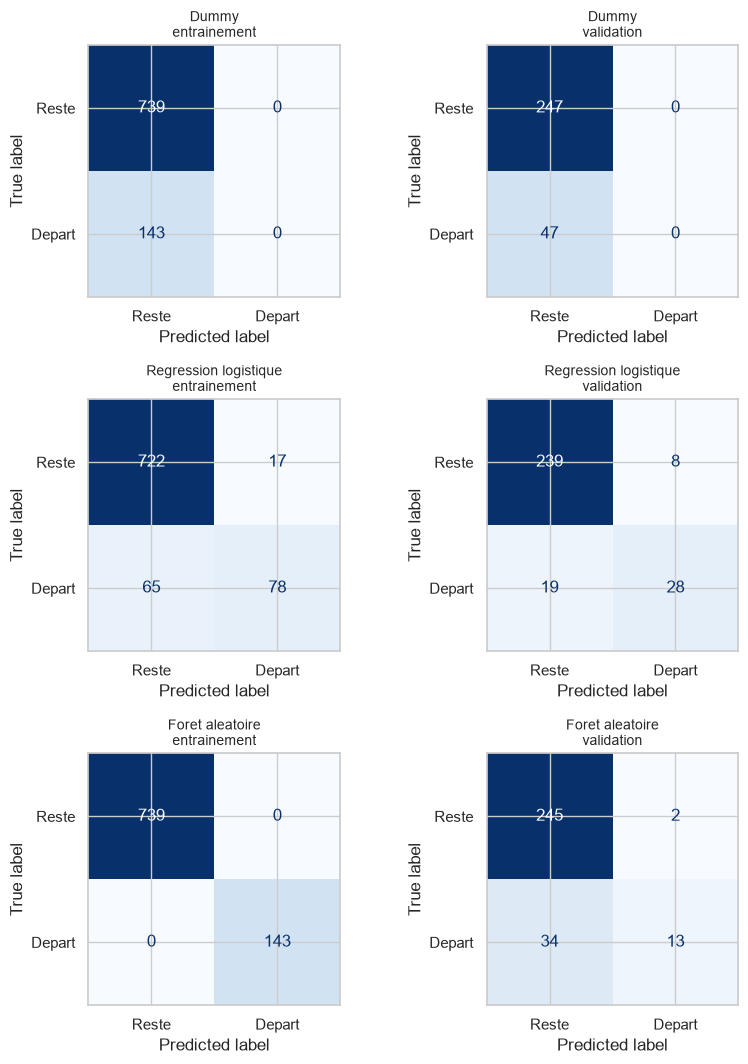

=== Dummy - jeu de validation ===
              precision    recall  f1-score   support

       Reste       0.84      1.00      0.91       247
      Depart       0.00      0.00      0.00        47

    accuracy                           0.84       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.71      0.84      0.77       294

=== Regression logistique - jeu de validation ===
              precision    recall  f1-score   support

       Reste       0.93      0.97      0.95       247
      Depart       0.78      0.60      0.67        47

    accuracy                           0.91       294
   macro avg       0.85      0.78      0.81       294
weighted avg       0.90      0.91      0.90       294

=== Foret aleatoire - jeu de validation ===
              precision    recall  f1-score   support

       Reste       0.88      0.99      0.93       247
      Depart       0.87      0.28      0.42        47

    accuracy                           0.88       294


In [ ]:
afficher_matrices_confusion(MODELES_REFERENCE, JEUX)

for nom_modele, modele in MODELES_REFERENCE.items():
    print(f"=== {nom_modele} - jeu de validation ===")
    print(
        classification_report(
            y_val,
            predire(modele, X_val),
            target_names=["Reste", "Depart"],
            zero_division=0,
        )
    )

**Ce que j'en retiens.**

**Le Dummy montre pourquoi l'accuracy est trompeuse.** Il obtient 84,0 % d'accuracy sur la validation sans détecter un seul des 47 départs : rappel 0, précision 0. Un modèle qui ne sert à rien paraît donc bon si on ne regarde que l'accuracy. C'est le plancher à dépasser, et la raison pour laquelle je juge les modèles sur le rappel, la précision et le F2.

**La régression logistique apprend quelque chose d'utile, mais rate encore quatre départs sur dix.** Sur la validation, elle détecte 28 départs sur 47 (rappel 0,596), et 28 de ses 36 alertes sont justes (précision 0,778). Ses scores d'entraînement et de validation sont très proches (F2 de 0,585 contre 0,625) : elle généralise bien, elle est surtout trop prudente. Au seuil de 0,5, face à 84 % de collaborateurs qui restent, elle ne prédit « départ » que lorsqu'elle en est très sûre.

**La forêt aléatoire apprend l'entraînement par coeur.** Toutes ses métriques valent 1,000 sur l'entraînement, et elle ne détecte que 13 départs sur 47 en validation (rappel 0,277). C'est un surapprentissage massif : sans contrainte, chaque arbre isole chaque collaborateur dans sa propre feuille.

**Ce que ces trois modèles disent du jeu de données.** Le modèle non linéaire ne fait pas mieux que le modèle linéaire, il fait même nettement moins bien (précision moyenne de 0,576 contre 0,696 en validation). Le problème n'est donc pas fortement non linéaire : une frontière simple capte déjà l'essentiel du signal. Les deux vrais problèmes sont le **déséquilibre des classes**, qui rend les modèles trop prudents, et le **surapprentissage** du modèle à base d'arbres. C'est exactement ce que traitent l'étape 4 (pondération, seuil) et l'étape 5 (réglage des hyperparamètres).

---
# Partie B - Étape 4 : déséquilibre des classes et contexte métier

## 4. Mon approche, posée avant de coder

| Question | Mon choix | Raison |
|---|---|---|
| Découpage | La séparation stratifiée 60 / 20 / 20 de l'étape 3, inchangée | Les résultats restent comparables d'une étape à l'autre |
| Comparaison des variantes | Validation croisée stratifiée à 5 plis, **sur l'entraînement uniquement** | Cinq mesures au lieu d'une : la comparaison ne dépend pas d'un découpage chanceux. La validation et le test restent intacts |
| Lecture des résultats | Moyenne et écart-type de chaque métrique sur les 5 plis, entraînement et validation | L'écart-type dit si une différence entre deux variantes est réelle ou due au hasard du découpage. L'écart entraînement / validation mesure le surapprentissage |
| Critère de choix | F2 et précision moyenne (AUC-PR) | Voir l'en-tête : le rappel compte plus que la précision |
| Déséquilibre | D'abord la pondération des classes, SMOTE seulement ensuite si elle ne suffit pas | Recommandation de l'énoncé : la pondération ne crée aucune donnée artificielle |
| Seuil de décision | Choisi sur la courbe précision-rappel des prédictions hors pli de l'entraînement, puis vérifié sur la validation | Le seuil de 0,5 n'a aucune justification métier. La validation ne compte que 47 départs : un seuil optimisé dessus suivrait le hasard de ces 47 cas |

Je sépare les expériences en sections, une question à la fois : quel modèle non linéaire et quelle pondération, puis l'apport des features créées au notebook 01, puis SMOTE, puis le seuil.

In [ ]:
def valider_en_croise(
    modeles: Mapping[str, BaseEstimator],
    X_jeu: pd.DataFrame,
    y_jeu: pd.Series,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Validation croisee : metriques de chaque pli, puis moyenne et ecart-type par modele."""
    plis = []
    for nom_modele, modele in modeles.items():
        scores = cross_validate(
            modele,
            X_jeu,
            y_jeu,
            cv=VALIDATION_CROISEE,
            scoring=METRIQUES_VALIDATION_CROISEE,
            return_train_score=True,
            n_jobs=-1,
        )
        # Une ligne par pli : les listes de scores de chaque iteration sont conservees
        for numero_pli in range(VALIDATION_CROISEE.get_n_splits()):
            ligne = {"modele": nom_modele, "pli": numero_pli + 1}
            for metrique in METRIQUES_VALIDATION_CROISEE:
                ligne[f"{metrique}_validation"] = scores[f"test_{metrique}"][numero_pli]
                ligne[f"{metrique}_entrainement"] = scores[f"train_{metrique}"][
                    numero_pli
                ]
            plis.append(ligne)

    detail_plis = pd.DataFrame(plis)
    synthese = (
        detail_plis.drop(columns="pli")
        .groupby("modele", sort=False)
        .agg(["mean", "std"])
    )
    synthese.columns = [
        f"{metrique}_{statistique}" for metrique, statistique in synthese.columns
    ]
    colonnes_lecture = [
        "f2_validation_mean",
        "f2_validation_std",
        "f2_entrainement_mean",
        "auc_pr_validation_mean",
        "auc_pr_validation_std",
        "rappel_validation_mean",
        "precision_validation_mean",
    ]
    return detail_plis, synthese[colonnes_lecture].round(3)

## 5. Expérience 1 : quel modèle non linéaire, et quelle pondération des classes ?

**Méthode.** La pondération fait compter davantage chaque départ dans l'apprentissage : avec `class_weight="balanced"`, un départ pèse environ cinq fois plus qu'un collaborateur qui reste, ce qui compense leur rareté. Je compare :
- la forêt aléatoire de l'étape 3, sans pondération ;
- la même forêt avec `class_weight="balanced"` ;
- la forêt pondérée avec des feuilles d'au moins 10 collaborateurs (`min_samples_leaf=10`). Un arbre non contraint isole chaque individu dans sa propre feuille : la pondération n'a alors plus rien à rééquilibrer ;
- XGBoost, un autre modèle à base d'arbres, pondéré par `scale_pos_weight` (le rapport entre restants et partants de l'entraînement, l'équivalent de `class_weight`).

J'ajoute la régression logistique pondérée comme point de repère linéaire. L'énoncé demande un modèle non linéaire, mais je veux savoir honnêtement ce qu'il apporte.

In [ ]:
RAPPORT_CLASSES = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"Rapport restants / partants sur l'entrainement : {RAPPORT_CLASSES:.2f}")

MODELES_PONDERATION = {
    "Foret aleatoire": MODELES_REFERENCE["Foret aleatoire"],
    "Foret aleatoire ponderee": RandomForestClassifier(
        class_weight="balanced", random_state=config.RANDOM_STATE, n_jobs=-1
    ),
    "Foret aleatoire ponderee, feuilles >= 10": RandomForestClassifier(
        class_weight="balanced",
        min_samples_leaf=10,
        random_state=config.RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost pondere": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        scale_pos_weight=RAPPORT_CLASSES,
        eval_metric="logloss",
        random_state=config.RANDOM_STATE,
        n_jobs=-1,
    ),
    "Regression logistique ponderee (repere lineaire)": Pipeline(
        [
            ("echelle", StandardScaler()),
            (
                "modele",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=config.RANDOM_STATE,
                ),
            ),
        ]
    ),
}

plis_ponderation, synthese_ponderation = valider_en_croise(
    MODELES_PONDERATION, X_train, y_train
)
display(synthese_ponderation)

Rapport restants / partants sur l'entrainement : 5.17


,f2_validation_mean,f2_validation_std,f2_entrainement_mean,auc_pr_validation_mean,auc_pr_validation_std,rappel_validation_mean,precision_validation_mean
modele,,,,,,,
Foret aleatoire,0.190,0.061,1.000,0.554,0.056,0.161,0.771
Foret aleatoire ponderee,0.371,0.099,1.000,0.553,0.070,0.335,0.676
"Foret aleatoire ponderee, feuilles >= 10",0.581,0.039,0.854,0.542,0.074,0.623,0.460
XGBoost pondere,0.550,0.040,0.986,0.590,0.051,0.552,0.543
Regression logistique ponderee (repere lineaire),0.629,0.016,0.723,0.616,0.056,0.734,0.404


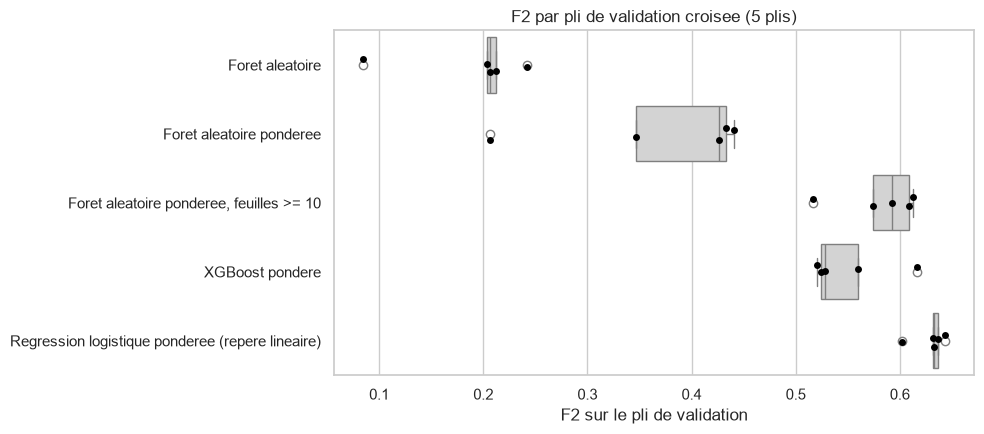

In [ ]:
# Dispersion du F2 sur les 5 plis : un ecart entre deux modeles n'a de sens
# que s'il depasse cette dispersion
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(
    data=plis_ponderation, y="modele", x="f2_validation", color="lightgrey", ax=ax
)
sns.stripplot(
    data=plis_ponderation, y="modele", x="f2_validation", color="black", size=5, ax=ax
)
ax.set_xlabel("F2 sur le pli de validation")
ax.set_ylabel("")
ax.set_title("F2 par pli de validation croisee (5 plis)")
plt.tight_layout()
plt.show()

**Ce que j'en retiens, et ma décision.**

- **La pondération seule améliore peu une forêt non contrainte** : le F2 passe de 0,190 à 0,371, mais le F2 d'entraînement reste à 1,000. Chaque feuille ne contient qu'un seul collaborateur : il ne reste presque rien à rééquilibrer.
- **Contraindre les feuilles rend la pondération efficace** : avec au moins 10 collaborateurs par feuille, le F2 de validation monte à 0,581 et l'écart avec l'entraînement se réduit (0,854).
- **XGBoost pondéré obtient la meilleure précision moyenne des modèles non linéaires** (0,590 contre 0,542 à 0,554 pour les forêts), et la plus stable d'entre eux d'un pli à l'autre (écart-type de 0,051). Son F2 au seuil de 0,5 est un peu plus bas que celui de la forêt contrainte (0,550 contre 0,581), mais ce seuil sera recalculé à la section 8 : c'est la précision moyenne, indépendante du seuil, qui compare le mieux la capacité des modèles à classer les collaborateurs par risque.
- **La régression logistique pondérée fait mieux que tous les modèles non linéaires** : F2 de 0,629, le plus stable de tous (écart-type de 0,016), et précision moyenne de 0,616, avec un écart entraînement / validation bien plus faible (F2 de 0,723 contre 0,629).

**Je retiens XGBoost pondéré** comme modèle non linéaire pour la suite, conformément à l'énoncé. Son point faible est clair : un F2 d'entraînement de 0,986 contre 0,550 en validation croisée, soit un fort surapprentissage. Le réglage des hyperparamètres de l'étape 5 devra le réduire. La régression logistique me sert de repère jusqu'au bout :voyons si le modèle final le dépasse.

## 6. Expérience 2 : les features créées au notebook 01 apportent-elles quelque chose ?

**Question.** Les trois features métier créées à partir des données existantes (notebook 01, point 12) aident-elles le modèle à repérer les départs, et laquelle compte le plus ?

| Feature | Ce qu'elle mesure |
|---|---|
| `satisfaction_minimale` | Le point de rupture : la plus basse des quatre notes de satisfaction |
| `nouveau_responsable` | Un changement de responsable depuis moins d'un an |
| `debut_de_carriere` | Une expérience professionnelle totale de 2 ans au plus |

**Méthode.** Je compare les deux meilleurs modèles de l'expérience 1, le XGBoost pondéré et la régression logistique pondérée, en validation croisée sur l'entraînement, dans cinq variantes : sans aucune des trois features (`config.FEATURES_CREEES`), sans chacune d'elles à tour de rôle, et avec toutes. Les modèles et les plis sont identiques d'une variante à l'autre : l'écart mesure l'apport des colonnes retirées, et lui seul.

Les deux indicateurs binaires, `nouveau_responsable` et `debut_de_carriere`, ont été conçus pour un modèle linéaire : ils isolent les premières années, un seuil qu'un arbre peut trouver seul en coupant la variable en années, mais pas une régression logistique. Je m'attends donc à ce qu'ils aident surtout la régression logistique.

In [ ]:
print(
    f"X : {X.shape[1]} features, dont {len(config.FEATURES_CREEES)} creees au notebook 01"
)
display(X[list(config.FEATURES_CREEES)].describe().round(2))

X : 46 features, dont 3 creees au notebook 01


,satisfaction_minimale,nouveau_responsable,debut_de_carriere
count,1470.00,1470.00,1470.00
mean,1.66,0.18,0.08
std,0.75,0.38,0.28
min,1.00,0.00,0.00
25%,1.00,0.00,0.00
50%,1.00,0.00,0.00
75%,2.00,0.00,0.00
max,4.00,1.00,1.00


In [ ]:
MODELE_NON_LINEAIRE = MODELES_PONDERATION["XGBoost pondere"]
MODELE_LINEAIRE_PONDERE = MODELES_PONDERATION[
    "Regression logistique ponderee (repere lineaire)"
]

# Memes modeles, memes plis : seules les colonnes changent d'une variante a l'autre
VARIANTES_FEATURES = {
    "sans les features creees": X_train.drop(columns=list(config.FEATURES_CREEES)),
    **{
        f"sans {feature}": X_train.drop(columns=[feature])
        for feature in config.FEATURES_CREEES
    },
    "avec les features creees": X_train,
}
syntheses_variantes = []
for variante, X_variante in VARIANTES_FEATURES.items():
    _, synthese_variante = valider_en_croise(
        {
            f"XGBoost pondere - {variante}": MODELE_NON_LINEAIRE,
            f"Regression logistique ponderee - {variante}": MODELE_LINEAIRE_PONDERE,
        },
        X_variante,
        y_train,
    )
    syntheses_variantes.append(synthese_variante)
comparaison_features = pd.concat(syntheses_variantes).sort_index()
display(comparaison_features)

# Reference des experiences suivantes : le XGBoost pondere avec toutes les features
synthese_avec_features_creees = comparaison_features.loc[
    ["XGBoost pondere - avec les features creees"]
]

,f2_validation_mean,f2_validation_std,f2_entrainement_mean,auc_pr_validation_mean,auc_pr_validation_std,rappel_validation_mean,precision_validation_mean
modele,,,,,,,
Regression logistique ponderee - avec les features creees,0.629,0.016,0.723,0.616,0.056,0.734,0.404
Regression logistique ponderee - sans debut_de_carriere,0.623,0.029,0.721,0.601,0.065,0.734,0.392
Regression logistique ponderee - sans les features creees,0.616,0.032,0.697,0.580,0.066,0.734,0.379
Regression logistique ponderee - sans nouveau_responsable,0.622,0.022,0.720,0.609,0.069,0.720,0.407
Regression logistique ponderee - sans satisfaction_minimale,0.602,0.042,0.707,0.614,0.052,0.699,0.390
XGBoost pondere - avec les features creees,0.550,0.040,0.986,0.590,0.051,0.552,0.543
XGBoost pondere - sans debut_de_carriere,0.550,0.040,0.986,0.590,0.051,0.552,0.543
XGBoost pondere - sans les features creees,0.513,0.027,0.985,0.578,0.060,0.524,0.476
XGBoost pondere - sans nouveau_responsable,0.550,0.040,0.986,0.590,0.051,0.552,0.543


**Ce que j'en retiens, et ma décision.**

| Précision moyenne en validation croisée | XGBoost pondéré | Régression logistique pondérée |
|---|---|---|
| Sans les trois features créées | 0,578 | 0,580 |
| Sans `satisfaction_minimale` | 0,578 | 0,614 |
| Sans `nouveau_responsable` | 0,590 | 0,609 |
| Sans `debut_de_carriere` | 0,590 | 0,601 |
| **Avec les trois features** | **0,590** | **0,616** |

- **Les features créées améliorent les deux modèles** : la précision moyenne gagne 1,2 point pour XGBoost et 3,6 points pour la régression logistique.
- **Les deux indicateurs binaires font exactement ce pour quoi ils ont été créés.** Ils n'apportent rien à XGBoost, dont les scores sont identiques avec ou sans eux : un arbre coupe déjà la variable en années au bon endroit. Ils apportent en revanche à la régression logistique, qui ne pouvait pas isoler seule les premières années : 1,5 point pour `debut_de_carriere` (0,601 sans elle), 0,7 point pour `nouveau_responsable` (0,609 sans elle).
- **`satisfaction_minimale` porte tout le gain de XGBoost** (0,578 sans elle, 0,590 avec). Pour la régression logistique, elle pèse peu sur la précision moyenne, car les quatre notes de satisfaction sont déjà dans le modèle, mais elle améliore la détection au seuil : sans elle, le rappel tombe de 0,734 à 0,699 et le F2 de 0,629 à 0,602.
- Chaque gain pris isolément reste du même ordre que la dispersion entre plis (écart-type de 0,05 à 0,07) : je ne peux pas les affirmer un par un avec certitude. Mais ils vont tous dans le sens attendu, pour les deux modèles.

**Je conserve les trois features** : elles améliorent les deux familles de modèles, chacune à sa façon, et chacune correspond à une action RH précise.

## 7. Expérience 3 : le suréchantillonnage SMOTE apporte-t-il plus que la pondération ?

**Méthode.** SMOTE crée des départs artificiels par interpolation entre deux départs voisins. Je le place dans un pipeline `imblearn` : il ne s'applique qu'aux plis d'entraînement de la validation croisée, jamais au pli de validation. Appliqué avant la validation croisée, il ferait évaluer le modèle sur des voisins synthétiques de ses propres exemples d'entraînement, et les scores seraient trop optimistes.

Pour isoler l'effet de SMOTE, je compare le même XGBoost, sur toutes les features :
- avec pondération seule (le modèle de l'expérience 2) ;
- avec SMOTE seul, sans pondération (sinon le déséquilibre serait corrigé deux fois).

In [11]:
XGBOOST_SANS_PONDERATION = MODELE_NON_LINEAIRE.get_params() | {"scale_pos_weight": 1.0}

plis_smote, synthese_smote = valider_en_croise(
    {
        "XGBoost + SMOTE": PipelineImb(
            [
                ("smote", SMOTE(random_state=config.RANDOM_STATE)),
                ("modele", XGBClassifier(**XGBOOST_SANS_PONDERATION)),
            ]
        )
    },
    X_train,
    y_train,
)
display(pd.concat([synthese_avec_features_creees, synthese_smote]))

,f2_validation_mean,f2_validation_std,f2_entrainement_mean,auc_pr_validation_mean,auc_pr_validation_std,rappel_validation_mean,precision_validation_mean
modele,,,,,,,
XGBoost pondere - avec les features creees,0.550,0.040,0.986,0.590,0.051,0.552,0.543
XGBoost + SMOTE,0.466,0.042,0.896,0.574,0.067,0.440,0.633


**Ce que j'en retiens, et ma décision.** SMOTE fait moins bien que la pondération sur les métriques qui comptent ici : F2 de 0,466 contre 0,550, rappel de 0,440 contre 0,552, et une précision moyenne de 0,574 contre 0,590, avec une dispersion plus forte entre plis (0,067 contre 0,051). Sa seule amélioration porte sur la précision (0,633 contre 0,543), c'est-à-dire l'inverse de ce que le métier demande. Les départs synthétiques, interpolés entre deux départs réels, n'apportent pas d'information nouvelle.

**Je garde la pondération seule.** L'énoncé recommande SMOTE uniquement si la pondération ne suffit pas : ce n'est pas le cas ici.

## 8. Modèle de l'étape 4 : entraînement et seuil choisi sur la courbe précision-rappel

**Question.** À partir de quelle probabilité de départ faut-il déclencher un entretien ?

Le seuil de 0,5 suppose qu'un faux négatif et un faux positif coûtent autant, ce qui est faux ici. Le seuil est un choix métier : plus il est bas, plus on détecte de départs, mais plus on mène d'entretiens inutiles.

**Méthode.** Pour choisir le seuil, il me faut des probabilités calculées sur des collaborateurs que le modèle n'a pas vus. Deux sources sont possibles :
- la **validation** : 294 collaborateurs, mais seulement 47 départs. Un seuil optimisé sur si peu de cas suit en partie leur hasard, et se transpose mal à de nouvelles données ;
- les **prédictions hors pli** de l'entraînement : avec `cross_val_predict`, chacun des 882 collaborateurs reçoit la probabilité calculée par un modèle entraîné sans lui. La courbe repose sur 143 départs, trois fois plus.

Je retiens la seconde source, et je trace la courbe précision-rappel pour garder le seuil qui maximise le F2. La validation garde alors son rôle de contrôle indépendant : si le seuil est bien choisi, le rappel et la précision mesurés dessus doivent rester proches de ceux de la courbe. Le test n'intervient pas.

La même fonction servira à l'étape 5, après le réglage des hyperparamètres.

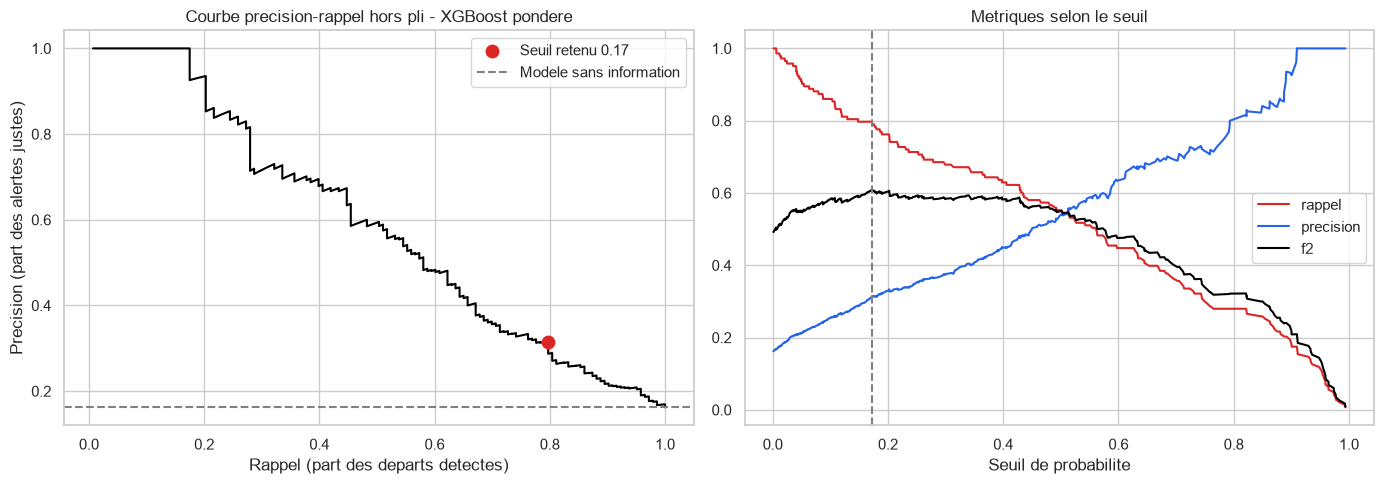

Seuil retenu : 0.172


,seuil,precision,rappel,f2
519,0.172,0.314,0.797,0.61


In [ ]:
def choisir_seuil(
    modele: BaseEstimator,
    X_jeu: pd.DataFrame,
    y_jeu: pd.Series,
    rappel_minimal: float | None = None,
    nb_decoupages: int = 1,
) -> tuple[float, pd.DataFrame]:
    """Seuil choisi sur des probabilites hors pli, et la courbe associee.

    Sans rappel minimal, le seuil maximise le F2. Avec un rappel minimal, c'est le seuil le plus
    haut qui atteint ce rappel : le moins de fausses alertes possible a ce niveau de detection.
    Le premier decoupage est celui de VALIDATION_CROISEE ; les suivants ne changent que la graine.
    """
    probabilites = np.mean(
        [
            cross_val_predict(
                modele,
                X_jeu,
                y_jeu,
                cv=StratifiedKFold(
                    n_splits=VALIDATION_CROISEE.get_n_splits(),
                    shuffle=True,
                    random_state=config.RANDOM_STATE + numero_decoupage,
                ),
                method="predict_proba",
                n_jobs=-1,
            )[:, 1]
            for numero_decoupage in range(nb_decoupages)
        ],
        axis=0,
    )
    precisions, rappels, seuils = precision_recall_curve(y_jeu, probabilites)
    beta_carre = config.BETA_F2**2
    f2 = (
        (1 + beta_carre)
        * precisions
        * rappels
        / (beta_carre * precisions + rappels + 1e-12)
    )
    # Le dernier point de la courbe n'a pas de seuil associe
    courbe = pd.DataFrame(
        {
            "seuil": seuils,
            "precision": precisions[:-1],
            "rappel": rappels[:-1],
            "f2": f2[:-1],
        }
    )
    if rappel_minimal is None:
        position = courbe["f2"].idxmax()
    else:
        # Seuils croissants : le dernier qui garde le rappel minimal emet le moins d'alertes
        position = courbe.index[courbe["rappel"] >= rappel_minimal].max()
    return float(courbe.loc[position, "seuil"]), courbe


def tracer_courbe_seuil(
    courbe: pd.DataFrame, seuil: float, taux_depart: float, titre: str
) -> None:
    """Courbe precision-rappel et evolution des metriques selon le seuil."""
    point = courbe.loc[(courbe["seuil"] - seuil).abs().idxmin()]
    fig, (ax_pr, ax_seuil) = plt.subplots(1, 2, figsize=(14, 5))

    ax_pr.plot(courbe["rappel"], courbe["precision"], color="black")
    ax_pr.scatter(
        point["rappel"],
        point["precision"],
        color=config.COULEUR_DEPART,
        s=80,
        zorder=3,
        label=f"Seuil retenu {seuil:.2f}",
    )
    ax_pr.axhline(
        taux_depart, linestyle="--", color="grey", label="Modele sans information"
    )
    ax_pr.set_xlabel("Rappel (part des departs detectes)")
    ax_pr.set_ylabel("Precision (part des alertes justes)")
    ax_pr.set_title(f"Courbe precision-rappel hors pli - {titre}")
    ax_pr.legend()

    for metrique, couleur in [
        ("rappel", config.COULEUR_DEPART),
        ("precision", config.COULEUR_RESTE),
        ("f2", "black"),
    ]:
        ax_seuil.plot(courbe["seuil"], courbe[metrique], label=metrique, color=couleur)
    ax_seuil.axvline(seuil, linestyle="--", color="grey")
    ax_seuil.set_xlabel("Seuil de probabilite")
    ax_seuil.set_title("Metriques selon le seuil")
    ax_seuil.legend()
    plt.tight_layout()
    plt.show()


seuil_etape4, courbe_etape4 = choisir_seuil(MODELE_NON_LINEAIRE, X_train, y_train)
tracer_courbe_seuil(courbe_etape4, seuil_etape4, y_train.mean(), "XGBoost pondere")

# Entrainement du modele de l'etape 4 sur tout l'entrainement
MODELE_NON_LINEAIRE.fit(X_train, y_train)
print(f"Seuil retenu : {seuil_etape4:.3f}")
display(courbe_etape4.loc[courbe_etape4["f2"].idxmax()].round(3).to_frame().T)

**Ce que j'en retiens, et ma décision.** Le F2 est maximal pour un seuil de **0,172**, très loin du 0,5 par défaut. À ce seuil, sur les prédictions hors pli, le modèle détecte 80 % des départs (rappel de 0,797) et 3 alertes sur 10 correspondent à un vrai départ (précision de 0,314). Le F2 hors pli atteint 0,610, contre 0,550 en validation croisée au seuil de 0,5.

La courbe de droite montre le compromis : en abaissant le seuil, le rappel monte tandis que la précision baisse, jusqu'à ce point d'équilibre. Pour le métier, cela revient à accepter environ deux entretiens de rétention « pour rien » pour chaque départ réellement anticipé. Ce compromis est acceptable si un entretien coûte nettement moins cher qu'un remplacement, ce qui est l'hypothèse de départ. Un seuil aussi bas signale aussi que les probabilités de ce modèle sont mal étalées : le surapprentissage les pousse vers les extrêmes.

## 9. Modèle de l'étape 4 : évaluation sur l'entraînement et la validation

**Méthode.** J'évalue le modèle entraîné au seuil par défaut et au seuil choisi, sur l'entraînement et sur la validation. La comparaison des deux lignes « validation » montre ce que le seuil apporte sur des données non vues ; la comparaison entraînement / validation mesure le surapprentissage.

,modele,jeu,seuil,accuracy,precision,rappel,f2,auc_pr
0,XGBoost pondere (etape 4),entrainement,0.500,0.982,0.904,0.993,0.974,0.998
1,XGBoost pondere (etape 4),validation,0.500,0.813,0.429,0.511,0.492,0.562
2,XGBoost pondere (etape 4),entrainement,0.172,0.772,0.416,1.000,0.781,0.998
3,XGBoost pondere (etape 4),validation,0.172,0.639,0.278,0.787,0.576,0.562


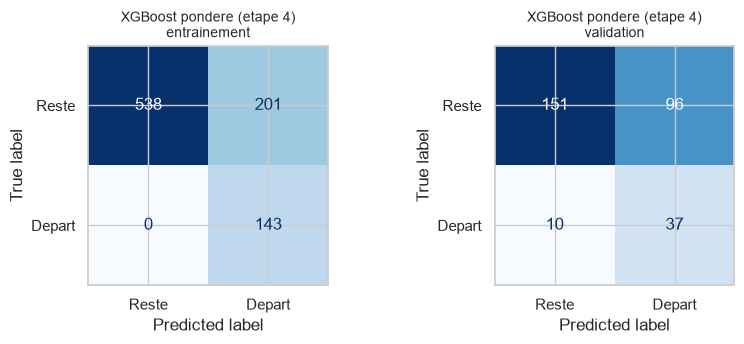

              precision    recall  f1-score   support

       Reste       0.94      0.61      0.74       247
      Depart       0.28      0.79      0.41        47

    accuracy                           0.64       294
   macro avg       0.61      0.70      0.58       294
weighted avg       0.83      0.64      0.69       294



In [13]:
NOM_ETAPE4 = "XGBoost pondere (etape 4)"
MODELE_ETAPE4 = {NOM_ETAPE4: MODELE_NON_LINEAIRE}
resultats_etape4 = pd.concat(
    [
        evaluer_modeles(MODELE_ETAPE4, JEUX),
        evaluer_modeles(MODELE_ETAPE4, JEUX, seuils={NOM_ETAPE4: seuil_etape4}),
    ],
    ignore_index=True,
)
display(resultats_etape4)

afficher_matrices_confusion(MODELE_ETAPE4, JEUX, seuils={NOM_ETAPE4: seuil_etape4})
print(
    classification_report(
        y_val,
        predire(MODELE_NON_LINEAIRE, X_val, seuil_etape4),
        target_names=["Reste", "Depart"],
    )
)

**Ce que j'en retiens.**

**Le seuil améliore fortement la détection sur la validation.** Au seuil de 0,5, XGBoost détecte 24 départs sur 47 (rappel de 0,511). Au seuil de 0,172, il en détecte 37 (rappel de 0,787) et n'en manque que 10. En contrepartie, il émet 96 fausses alertes sur les 247 collaborateurs qui restent (précision de 0,278), soit 133 entretiens pour 294 collaborateurs. Le F2 de validation passe de 0,492 à 0,576.

**Mais il reste en dessous du modèle linéaire, et le surapprentissage n'est pas réglé.** La régression logistique de l'étape 3, sans pondération et au seuil de 0,5, atteignait déjà un F2 de 0,625 sur cette même validation. Le F2 de validation de XGBoost (0,576) reste aussi en dessous du F2 hors pli (0,610) qui a servi à choisir le seuil. Sur l'entraînement, le modèle détecte 100 % des départs et sa précision moyenne atteint 0,998, contre 0,562 sur la validation : il a appris une grande partie de l'entraînement par coeur. Ses probabilités sont donc peu fiables sur de nouveaux collaborateurs. C'est ce que le réglage de l'étape 5 doit corriger.

---
# Partie C - Étape 5 : réglage fin des hyperparamètres

## 10. Recherche sur grille

**Question.** Des hyperparamètres mieux choisis améliorent-ils le classement des collaborateurs par risque, et réduisent-ils le surapprentissage ?

**Méthode.** `GridSearchCV` sur le XGBoost pondéré, en validation croisée à 5 plis sur l'entraînement seulement, puis sur la régression logistique pondérée (plus bas). Je règle les hyperparamètres qui contrôlent la complexité des arbres et la vitesse d'apprentissage :

| Hyperparamètre | Rôle |
|---|---|
| `max_depth` | Profondeur des arbres : plus ils sont profonds, plus ils captent d'interactions, et plus ils risquent d'apprendre par coeur |
| `learning_rate` et `n_estimators` | Vitesse d'apprentissage et nombre d'arbres, qui se compensent |
| `min_child_weight` | Poids minimal d'une feuille : empêche de créer une règle pour une poignée de collaborateurs |
| `subsample` et `colsample_bytree` | Part des lignes et des colonnes tirées pour chaque arbre : rend le modèle plus robuste |

**Critère de sélection : la précision moyenne (AUC-PR)**, et non le F2. Le F2 dépend du seuil, que je recalcule juste après : régler les hyperparamètres sur un F2 au seuil de 0,5 mélangerait les deux réglages. La précision moyenne mesure la qualité du classement sur tous les seuils à la fois. Je suis le F2 en parallèle pour contrôle.

In [ ]:
GRILLE_HYPERPARAMETRES = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [200, 400],
    "min_child_weight": [1, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.6, 1.0],
}

recherche = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=RAPPORT_CLASSES,
        eval_metric="logloss",
        random_state=config.RANDOM_STATE,
        n_jobs=1,
    ),
    param_grid=GRILLE_HYPERPARAMETRES,
    scoring={"auc_pr": "average_precision", "f2": SCORER_F2},
    refit="auc_pr",
    cv=VALIDATION_CROISEE,
    return_train_score=True,
    n_jobs=-1,
)
recherche.fit(X_train, y_train)

resultats_recherche = pd.DataFrame(recherche.cv_results_).sort_values(
    "rank_test_auc_pr"
)
colonnes_recherche = [
    "params",
    "mean_test_auc_pr",
    "std_test_auc_pr",
    "mean_train_auc_pr",
    "mean_test_f2",
]
print(f"Combinaisons testees : {len(resultats_recherche)}")
print(f"Meilleurs hyperparametres : {recherche.best_params_}")
display(resultats_recherche[colonnes_recherche].head(5).round(3))

# Point de comparaison : le modele de l'etape 4 sur les memes plis et le meme critere
display(
    synthese_avec_features_creees[
        ["auc_pr_validation_mean", "auc_pr_validation_std", "f2_validation_mean"]
    ]
)

Combinaisons testees : 144
Meilleurs hyperparametres : {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 400, 'subsample': 0.8}


,params,mean_test_auc_pr,std_test_auc_pr,mean_train_auc_pr,mean_test_f2
30,"{'colsample_bytree': 0.6, 'learning_rate': 0.0...",0.658,0.048,0.953,0.608
28,"{'colsample_bytree': 0.6, 'learning_rate': 0.0...",0.658,0.059,0.895,0.645
38,"{'colsample_bytree': 0.6, 'learning_rate': 0.0...",0.655,0.048,0.999,0.570
118,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.654,0.047,1.000,0.548
6,"{'colsample_bytree': 0.6, 'learning_rate': 0.0...",0.654,0.058,0.912,0.607


,auc_pr_validation_mean,auc_pr_validation_std,f2_validation_mean
modele,,,
XGBoost pondere - avec les features creees,0.59,0.051,0.55


**Ce que j'en retiens, et ma décision.** Sur 144 combinaisons, la meilleure retient des arbres très peu profonds (`max_depth=2`), 400 arbres avec un pas d'apprentissage de 0,05, au moins 5 collaborateurs pondérés par feuille (`min_child_weight=5`), 80 % des lignes et 60 % des colonnes par arbre. Sa précision moyenne en validation croisée atteint **0,658**, contre 0,590 pour le modèle de l'étape 4.

Trois lectures :
- **Le gain est réel mais à nuancer** (6,8 points) : l'écart-type entre plis est de 0,048, et les 5 meilleures combinaisons se tiennent entre 0,654 et 0,658. On atteint un plateau : le choix exact des hyperparamètres compte peu au-delà. Signe de ce plateau, d'autres versions de scikit-learn et de XGBoost désignent une autre combinaison du peloton de tête, pour une précision moyenne quasi identique ;
- **Le réglage retient une combinaison régularisée** : arbres de profondeur 2, feuilles contraintes, sous-échantillonnage des lignes et des colonnes. Sa précision moyenne d'entraînement est de 0,953, alors que plusieurs de ses voisines du classement montent à 0,999 ou 1,000. C'est le signe d'un surapprentissage réduit ;
- **Le modèle réglé dépasse la régression logistique pondérée par défaut** (0,658 contre 0,616), mais celle-ci n'a pas encore été réglée. C'est l'objet de la recherche suivante.

### Régression logistique pondérée : force de régularisation

**Question.** Le modèle linéaire gagne-t-il, lui aussi, à être réglé ?

**Méthode.** Même protocole que pour le XGBoost : `GridSearchCV` en validation croisée à 5 plis sur l'entraînement, sélection sur la précision moyenne, F2 suivi pour contrôle. Pour une régression logistique pondérée, l'hyperparamètre qui compte est la **force de régularisation** `C` : plus `C` est petit, plus les coefficients sont tirés vers zéro. Cela limite le surapprentissage et stabilise les coefficients de variables corrélées, comme le bloc âge / expérience / anciennetés. Je teste une grille logarithmique de 0,001 à 10 ; la valeur par défaut, utilisée jusqu'ici, est 1.

In [ ]:
NOM_REGRESSION_REGLEE = "Regression logistique reglee (etape 5)"
GRILLE_REGRESSION = {"modele__C": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]}

recherche_regression = GridSearchCV(
    estimator=MODELES_PONDERATION["Regression logistique ponderee (repere lineaire)"],
    param_grid=GRILLE_REGRESSION,
    scoring={"auc_pr": "average_precision", "f2": SCORER_F2},
    refit="auc_pr",
    cv=VALIDATION_CROISEE,
    return_train_score=True,
    n_jobs=-1,
)
recherche_regression.fit(X_train, y_train)

print(
    f"Meilleure force de regularisation : C = {recherche_regression.best_params_['modele__C']}"
)
display(
    pd.DataFrame(recherche_regression.cv_results_)
    .set_index("param_modele__C")[
        ["mean_test_auc_pr", "std_test_auc_pr", "mean_train_auc_pr", "mean_test_f2"]
    ]
    .round(3)
)

Meilleure force de regularisation : C = 0.01


,mean_test_auc_pr,std_test_auc_pr,mean_train_auc_pr,mean_test_f2
param_modele__C,,,,
0.001,0.595,0.059,0.643,0.612
0.003,0.635,0.048,0.695,0.638
0.010,0.657,0.037,0.733,0.636
0.030,0.650,0.034,0.741,0.626
0.100,0.636,0.038,0.737,0.624
0.300,0.622,0.048,0.730,0.630
1.000,0.616,0.050,0.725,0.629
3.000,0.610,0.055,0.723,0.620
10.000,0.605,0.058,0.722,0.619


**Ce que j'en retiens, et ma décision.** La meilleure force de régularisation est **C = 0,01**, cent fois plus forte que la valeur par défaut. La précision moyenne en validation croisée passe de 0,616 à **0,657**, avec une dispersion plus faible entre plis (écart-type de 0,037 contre 0,050).

- **La courbe a un optimum net** : la précision moyenne monte de 0,595 (C = 0,001, régularisation trop forte) à 0,657 (C = 0,01), puis redescend lentement jusqu'à 0,605 (C = 10). Une régularisation forte tire vers zéro les coefficients des variables corrélées, dont le modèle répartissait le poids de façon instable.
- **Le surapprentissage reste faible** : 0,733 de précision moyenne en entraînement, contre 0,657 en validation croisée.
- **Les deux modèles réglés se rejoignent** : 0,657 pour la régression logistique, 0,658 pour XGBoost, un écart négligeable. La régression logistique y parvient avec un écart entraînement / validation nettement plus faible (0,076 contre 0,295).

**Je garde les deux modèles réglés comme candidats.** Le choix final se fera à la section 12, dans les mêmes conditions pour tous les modèles.

## 11. Seuil du modèle réglé et comparaison sur la validation

**Méthode.** `GridSearchCV` a réentraîné la meilleure combinaison sur tout l'entraînement. Ses probabilités ne sont plus celles du modèle de l'étape 4 : je recalcule le seuil avec la même fonction, sur les prédictions hors pli de l'entraînement. Je compare ensuite les deux modèles, chacun à son propre seuil, sur l'entraînement et sur la validation. C'est sur cette comparaison, et non sur le test, que je choisis le modèle final.

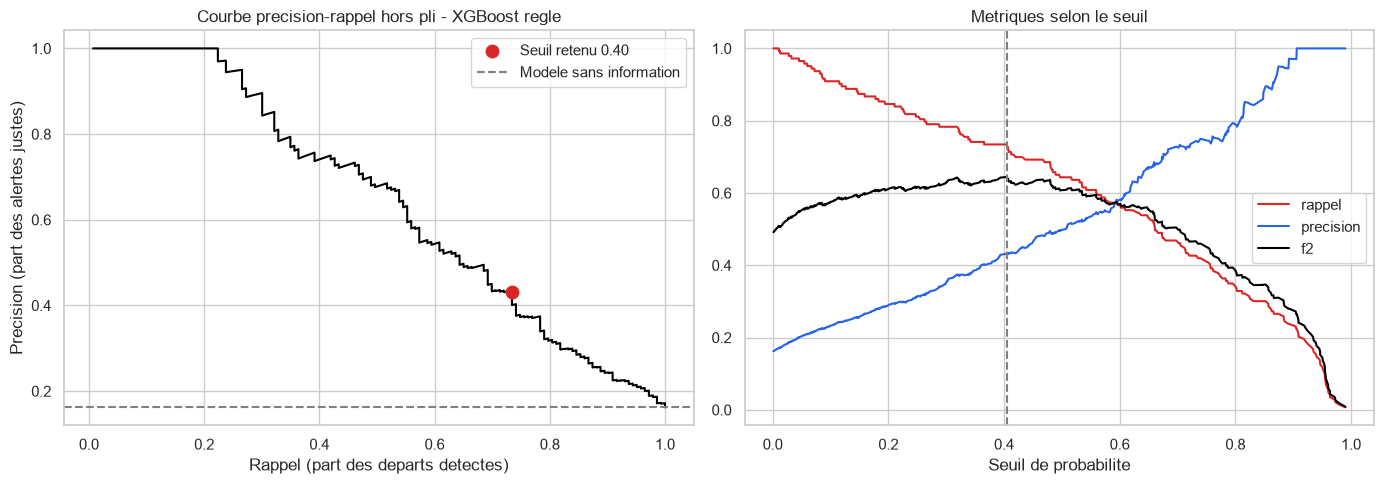

Seuil retenu pour le modele regle : 0.405


,modele,jeu,seuil,accuracy,precision,rappel,f2,auc_pr
0,XGBoost pondere (etape 4),entrainement,0.172,0.772,0.416,1.000,0.781,0.998
1,XGBoost pondere (etape 4),validation,0.172,0.639,0.278,0.787,0.576,0.562
2,XGBoost regle (etape 5),entrainement,0.405,0.873,0.564,0.958,0.840,0.936
3,XGBoost regle (etape 5),validation,0.405,0.755,0.356,0.660,0.564,0.579


In [16]:
NOM_ETAPE5 = "XGBoost regle (etape 5)"
MODELE_ETAPE5 = recherche.best_estimator_

seuil_etape5, courbe_etape5 = choisir_seuil(MODELE_ETAPE5, X_train, y_train)
tracer_courbe_seuil(courbe_etape5, seuil_etape5, y_train.mean(), "XGBoost regle")
print(f"Seuil retenu pour le modele regle : {seuil_etape5:.3f}")

MODELES_COMPARES = {NOM_ETAPE4: MODELE_NON_LINEAIRE, NOM_ETAPE5: MODELE_ETAPE5}
SEUILS_COMPARES = {NOM_ETAPE4: seuil_etape4, NOM_ETAPE5: seuil_etape5}
display(evaluer_modeles(MODELES_COMPARES, JEUX, SEUILS_COMPARES))

**Ce que j'en retiens, et ma décision.**

| Sur la validation (294 collaborateurs, 47 départs) | Étape 4 (seuil 0,172) | Étape 5 (seuil 0,405) |
|---|---|---|
| Départs détectés | 37 | 31 |
| Fausses alertes | 96 | 56 |
| Précision moyenne (AUC-PR) | 0,562 | 0,579 |
| F2 | 0,576 | 0,564 |
| Précision moyenne sur l'entraînement | 0,998 | 0,936 |

Les deux modèles font des compromis différents au seuil : celui de l'étape 4 détecte 6 départs de plus, au prix de 40 fausses alertes de plus, et leurs F2 sont proches (0,576 contre 0,564). Le réglage apporte surtout ailleurs :
- il **classe un peu mieux les collaborateurs par risque** : précision moyenne de 0,579 contre 0,562 sur la validation, et de 0,658 contre 0,590 en validation croisée. C'est la métrique qui ne dépend pas du seuil, donc la plus fiable pour comparer deux modèles ;
- il **surapprend moins** : 0,936 de précision moyenne en entraînement contre 0,998, et son seuil (0,405) est moins extrême. Ses probabilités sont donc plus crédibles sur de nouveaux collaborateurs.

**Je retiens le modèle réglé comme meilleur XGBoost.** Il n'a cependant été comparé jusqu'ici qu'à des modèles placés dans d'autres conditions. La section suivante met tous les modèles à égalité avant le choix final : mêmes features, même règle de seuil, entraînement sur 1 176 collaborateurs.

## 12. Comparaison de tous les modèles, réentraînés sur l'entraînement et la validation

**Question.** Maintenant que les features, la pondération et les hyperparamètres sont fixés, quel modèle retenir, et avec quel seuil ?

**Pourquoi réunir l'entraînement et la validation.** La validation a rempli son rôle : elle a servi aux choix des étapes 3 à 5. Le garder à l'écart priverait le modèle final de 294 collaborateurs, dont 47 départs, soit un tiers de données en plus. Avec si peu de départs, chaque exemple compte : la partie D mesure ce que ce tiers de données en plus apporte.

**Méthode.**
- Je réentraîne **tous les modèles du notebook** sur les 1 176 collaborateurs de l'entraînement et de la validation réunis, avec toutes les features : les forêts aléatoires (simple, pondérée, pondérée à feuilles contraintes), la régression logistique pondérée, la régression logistique réglée et le XGBoost réglé de l'étape 5, le XGBoost pondéré de l'étape 4. Le Dummy est écarté : il ne classe personne, aucun seuil ne peut le rendre utile.
- Pour chacun, le seuil est fixé sur des **probabilités hors pli**, moyennées sur 5 découpages pour être plus stables.
- **Règle de choix, traduite de la préférence du commanditaire** (`config.RAPPEL_MINIMAL`) : une fausse alerte coûte moins cher qu'un départ manqué. Chaque modèle reçoit le seuil le plus haut qui détecte au moins 80 % des départs hors pli. À ce niveau de détection égal, je retiens le modèle le plus **précis**, c'est-à-dire celui qui émet le moins de fausses alertes.
- La précision moyenne (AUC-PR) en validation croisée complète la lecture : elle mesure le classement des collaborateurs par risque, indépendamment du seuil.

Le test reste fermé : il ne sert qu'à la partie D.

In [ ]:
# Entrainement et validation reunis : memes features et memes collaborateurs qu'aux etapes 3 a 5
X_entrainement_validation = pd.concat([X_train, X_val])
y_entrainement_validation = pd.concat([y_train, y_val])
print(
    f"Entrainement + validation : {len(y_entrainement_validation)} collaborateurs, "
    f"{int(y_entrainement_validation.sum())} departs"
)

# Tous les modeles du notebook, sauf le Dummy ; le XGBoost pondere de MODELES_PONDERATION est celui de l'etape 4
MODELES_CANDIDATS = MODELES_PONDERATION | {
    NOM_ETAPE5: MODELE_ETAPE5,
    NOM_REGRESSION_REGLEE: recherche_regression.best_estimator_,
}

_, synthese_candidats = valider_en_croise(
    MODELES_CANDIDATS, X_entrainement_validation, y_entrainement_validation
)

lignes_comparaison, seuils_candidats, courbes_candidats = [], {}, {}
for nom_modele, modele in MODELES_CANDIDATS.items():
    seuil, courbe = choisir_seuil(
        modele,
        X_entrainement_validation,
        y_entrainement_validation,
        rappel_minimal=config.RAPPEL_MINIMAL,
        nb_decoupages=NB_DECOUPAGES_SEUIL,
    )
    point = courbe.loc[courbe["seuil"] == seuil].iloc[0]
    seuils_candidats[nom_modele], courbes_candidats[nom_modele] = seuil, courbe
    lignes_comparaison.append(
        {
            "modele": nom_modele,
            "seuil": seuil,
            "rappel_hors_pli": point["rappel"],
            "precision_hors_pli": point["precision"],
            "fausses_alertes_par_depart_detecte": (1 - point["precision"])
            / point["precision"],
            "f2_hors_pli": point["f2"],
            "auc_pr_validation_croisee": synthese_candidats.loc[
                nom_modele, "auc_pr_validation_mean"
            ],
            "auc_pr_ecart_type": synthese_candidats.loc[
                nom_modele, "auc_pr_validation_std"
            ],
        }
    )

comparaison_candidats = (
    pd.DataFrame(lignes_comparaison)
    .set_index("modele")
    .sort_values("precision_hors_pli", ascending=False)
)
display(comparaison_candidats.round(3))

Entrainement + validation : 1176 collaborateurs, 190 departs


,seuil,rappel_hors_pli,precision_hors_pli,fausses_alertes_par_depart_detecte,f2_hors_pli,auc_pr_validation_croisee,auc_pr_ecart_type
modele,,,,,,,
Regression logistique ponderee (repere lineaire),0.418,0.800,0.369,1.711,0.648,0.656,0.080
Regression logistique reglee (etape 5),0.432,0.800,0.340,1.941,0.630,0.661,0.059
XGBoost regle (etape 5),0.299,0.800,0.321,2.118,0.616,0.631,0.059
XGBoost pondere,0.234,0.800,0.315,2.171,0.612,0.588,0.066
Foret aleatoire,0.152,0.800,0.313,2.197,0.610,0.525,0.052
Foret aleatoire ponderee,0.244,0.805,0.307,2.261,0.608,0.520,0.063
"Foret aleatoire ponderee, feuilles >= 10",0.380,0.800,0.293,2.408,0.595,0.530,0.065


Modele final : Regression logistique ponderee (repere lineaire) | seuil 0.418


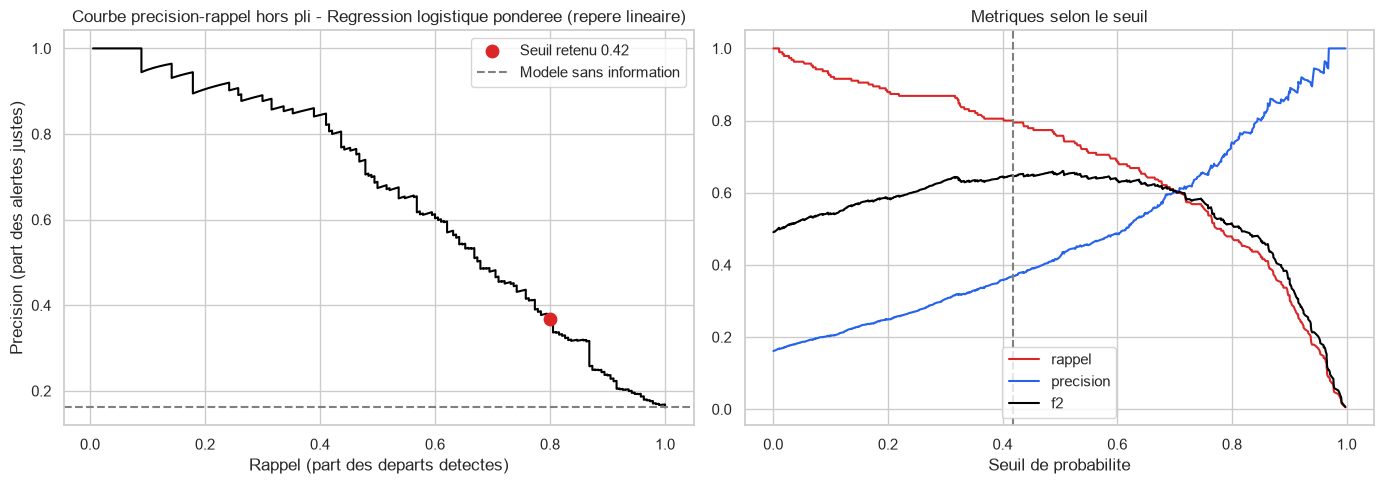

In [ ]:
# Choix du modele final : le plus precis a rappel hors pli d'au moins RAPPEL_MINIMAL
NOM_FINAL = comparaison_candidats.index[0]
seuil_final = seuils_candidats[NOM_FINAL]

# Chaque candidat est reentraine sur les 1 176 collaborateurs : le test de la partie D les mesurera tous
MODELES_REENTRAINES = {
    nom_modele: clone(modele).fit(X_entrainement_validation, y_entrainement_validation)
    for nom_modele, modele in MODELES_CANDIDATS.items()
}
MODELE_FINAL = MODELES_REENTRAINES[NOM_FINAL]

print(f"Modele final : {NOM_FINAL} | seuil {seuil_final:.3f}")
tracer_courbe_seuil(
    courbes_candidats[NOM_FINAL],
    seuil_final,
    y_entrainement_validation.mean(),
    NOM_FINAL,
)

**Ce que j'en retiens, et ma décision.**

| Hors pli, entraînement + validation (1 176 collaborateurs, 190 départs) | Seuil | Précision à 80 % de rappel | Fausses alertes par départ détecté | Précision moyenne (AUC-PR) |
|---|---|---|---|---|
| **Régression logistique pondérée (C = 1)** | 0,418 | **0,369** | **1,7** | 0,656 (écart-type 0,080) |
| Régression logistique réglée (C = 0,01) | 0,432 | 0,340 | 1,9 | **0,661** (0,059) |
| XGBoost réglé (étape 5) | 0,299 | 0,321 | 2,1 | 0,631 (0,059) |
| XGBoost pondéré (étape 4) | 0,234 | 0,315 | 2,2 | 0,588 (0,066) |
| Forêt aléatoire | 0,152 | 0,313 | 2,2 | 0,525 (0,052) |
| Forêt pondérée | 0,244 | 0,307 | 2,3 | 0,520 (0,063) |
| Forêt pondérée, feuilles >= 10 | 0,380 | 0,293 | 2,4 | 0,530 (0,065) |

**Je retiens la régression logistique pondérée, au seuil de 0,418**, en appliquant la règle fixée avec le commanditaire :
- **à détection égale, c'est elle qui émet le moins de fausses alertes** : 1,7 entretien « pour rien » par départ anticipé, contre 1,9 pour la version réglée, 2,1 pour le XGBoost réglé et 2,2 à 2,4 pour les autres modèles ;
- **elle classe aussi parmi les mieux les collaborateurs par risque** (précision moyenne de 0,656). La version réglée fait à peine mieux sur ce critère (0,661), avec un classement plus stable d'un pli à l'autre, mais elle émet plus de fausses alertes au seuil qui compte pour le métier. Avec 1 176 collaborateurs au lieu de 882, la forte régularisation qui l'avantageait à la section 10 devient probablement moins utile ;
- **elle est la plus simple à expliquer** : chaque feature a un effet constant et signé, lisible directement par un RH.

**Pourquoi le modèle linéaire l'emporte.** Avec 190 départs seulement, un modèle qui a peu de paramètres à estimer généralise mieux qu'un ensemble d'arbres : les effets de seuil que les arbres peuvent capter ne compensent pas leur plus forte variance, d'autant que `nouveau_responsable` et `debut_de_carriere` apportent désormais au modèle linéaire les principaux de ces effets de seuil.

Le test, ouvert à la partie D, dira si ce choix se confirme. Je ne le reverrai pas au vu du test.

---
# Partie D - Confirmation finale sur le test

## 13. Ouverture unique du jeu de test

**Question.** Les performances mesurées sur la validation tiennent-elles sur des collaborateurs jamais utilisés, et le modèle choisi reste-t-il le meilleur ?

**Méthode.** Tous les choix sont désormais figés : modèle, features, pondération, hyperparamètres, seuil. J'évalue **tous les modèles** du notebook sur l'entraînement et sur le test, chacun avec ses propres features et son propre seuil : les trois modèles de référence de l'étape 3, le modèle de l'étape 4 et le modèle réglé, entraînés sur l'entraînement seul, puis tous les modèles réentraînés sur l'entraînement et la validation à la section 12, dont le modèle final. Ce tableau complète l'étape 3, qui demande des métriques sur le test pour chaque modèle. Je ne revois aucun choix au vu de ces résultats : le test sert à mesurer, pas à choisir.

In [ ]:
# Modeles des etapes 3 a 5, entraines sur l'entrainement seul
resultats_test = pd.concat(
    [
        evaluer_modeles(
            MODELES_REFERENCE,
            {"entrainement": (X_train, y_train), "test": (X_test, y_test)},
        ),
        evaluer_modeles(
            MODELES_COMPARES,
            {"entrainement": (X_train, y_train), "test": (X_test, y_test)},
            SEUILS_COMPARES,
        ),
    ],
    ignore_index=True,
)
display(resultats_test)

# Modeles de la section 12, reentraines sur entrainement + validation, chacun a son seuil hors pli
resultats_test_reentraines = evaluer_modeles(
    MODELES_REENTRAINES,
    {
        "entrainement + validation": (
            X_entrainement_validation,
            y_entrainement_validation,
        ),
        "test": (X_test, y_test),
    },
    seuils_candidats,
)
tableau_test_reentraines = resultats_test_reentraines.query("jeu == 'test'").set_index(
    "modele"
)
tableau_test_reentraines.insert(
    3,
    "departs_detectes",
    (tableau_test_reentraines["rappel"] * y_test.sum()).round().astype(int),
)
tableau_test_reentraines.insert(
    4,
    "fausses_alertes",
    [
        int(
            (
                (predire(MODELES_REENTRAINES[nom], X_test, seuils_candidats[nom]) == 1)
                & (y_test == 0)
            ).sum()
        )
        for nom in tableau_test_reentraines.index
    ],
)
display(tableau_test_reentraines.loc[comparaison_candidats.index].drop(columns="jeu"))

# Ecart hors pli / test du modele final : mesure de l'optimisme du choix
point_final = comparaison_candidats.loc[NOM_FINAL]
ligne_test_finale = tableau_test_reentraines.loc[NOM_FINAL]
display(
    pd.DataFrame(
        {
            "hors pli (entrainement + validation)": [
                point_final["rappel_hors_pli"],
                point_final["precision_hors_pli"],
                point_final["f2_hors_pli"],
            ],
            "test": [
                ligne_test_finale["rappel"],
                ligne_test_finale["precision"],
                ligne_test_finale["f2"],
            ],
        },
        index=["rappel", "precision", "f2"],
    ).round(3)
)

,modele,jeu,seuil,accuracy,precision,rappel,f2,auc_pr
0,Dummy,entrainement,0.500,0.838,0.000,0.000,0.000,0.162
1,Dummy,test,0.500,0.840,0.000,0.000,0.000,0.160
2,Regression logistique,entrainement,0.500,0.907,0.821,0.545,0.585,0.753
3,Regression logistique,test,0.500,0.878,0.720,0.383,0.423,0.518
4,Foret aleatoire,entrainement,0.500,1.000,1.000,1.000,1.000,1.000
5,Foret aleatoire,test,0.500,0.823,0.308,0.085,0.100,0.373
6,XGBoost pondere (etape 4),entrainement,0.172,0.772,0.416,1.000,0.781,0.998
7,XGBoost pondere (etape 4),test,0.172,0.622,0.261,0.745,0.543,0.401
8,XGBoost regle (etape 5),entrainement,0.405,0.873,0.564,0.958,0.840,0.936
9,XGBoost regle (etape 5),test,0.405,0.738,0.326,0.596,0.511,0.462


,seuil,accuracy,departs_detectes,fausses_alertes,precision,rappel,f2,auc_pr
modele,,,,,,,,
Regression logistique ponderee (repere lineaire),0.418,0.748,36,63,0.364,0.766,0.627,0.531
Regression logistique reglee (etape 5),0.432,0.741,36,65,0.356,0.766,0.623,0.504
XGBoost regle (etape 5),0.299,0.701,39,80,0.328,0.830,0.635,0.513
XGBoost pondere,0.234,0.670,36,86,0.295,0.766,0.581,0.443
Foret aleatoire,0.152,0.684,38,84,0.311,0.809,0.613,0.398
Foret aleatoire ponderee,0.244,0.656,35,89,0.282,0.745,0.561,0.404
"Foret aleatoire ponderee, feuilles >= 10",0.380,0.633,39,100,0.281,0.830,0.596,0.403


,hors pli (entrainement + validation),test
rappel,0.800,0.766
precision,0.369,0.364
f2,0.648,0.627


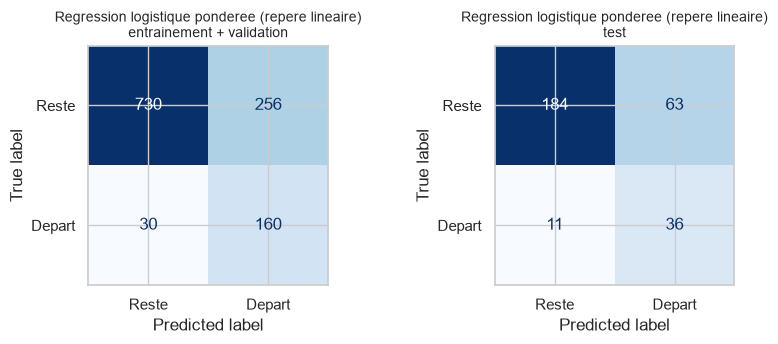

              precision    recall  f1-score   support

       Reste       0.94      0.74      0.83       247
      Depart       0.36      0.77      0.49        47

    accuracy                           0.75       294
   macro avg       0.65      0.76      0.66       294
weighted avg       0.85      0.75      0.78       294



In [ ]:
afficher_matrices_confusion(
    {NOM_FINAL: MODELE_FINAL},
    {
        "entrainement + validation": (
            X_entrainement_validation,
            y_entrainement_validation,
        ),
        "test": (X_test, y_test),
    },
    {NOM_FINAL: seuil_final},
)
print(
    classification_report(
        y_test,
        predire(MODELE_FINAL, X_test, seuil_final),
        target_names=["Reste", "Depart"],
    )
)

**Ce que j'en retiens.**

**Le choix fait hors pli tient sur le test.** La régression logistique réentraînée détecte 36 départs sur 47 (rappel de 0,766), avec 63 fausses alertes (précision de 0,364), soit 99 entretiens pour 294 collaborateurs. C'est le modèle qui émet le moins de fausses alertes par départ détecté, et sa précision moyenne (0,531) est la meilleure des modèles réentraînés :

| Sur le test (294 collaborateurs, 47 départs) | Entraîné sur | Seuil | Départs détectés | Fausses alertes | F2 | AUC-PR |
|---|---|---|---|---|---|---|
| Dummy | entraînement | 0,500 | 0 / 47 | 0 | 0,000 | 0,160 |
| Régression logistique (étape 3) | entraînement | 0,500 | 18 / 47 | 7 | 0,423 | 0,518 |
| XGBoost pondéré (étape 4) | entraînement | 0,172 | 35 / 47 | 99 | 0,543 | 0,401 |
| XGBoost réglé (étape 5) | entraînement | 0,405 | 28 / 47 | 58 | 0,511 | 0,462 |
| XGBoost réglé (étape 5) | entr. + valid. | 0,299 | 39 / 47 | 80 | 0,635 | 0,513 |
| Régression logistique réglée | entr. + valid. | 0,432 | 36 / 47 | 65 | 0,623 | 0,504 |
| Forêt pondérée, feuilles >= 10 | entr. + valid. | 0,380 | 39 / 47 | 100 | 0,596 | 0,403 |
| **Régression logistique pondérée (modèle final)** | **entr. + valid.** | **0,418** | **36 / 47** | **63** | **0,627** | **0,531** |

Quatre lectures :
- **Le seuil tient sur de nouveaux collaborateurs.** Le rappel passe de 0,800 hors pli à 0,766 sur le test, soit un à deux départs de moins que prévu, et la précision reste stable (0,364 contre 0,369).
- **Le XGBoost réglé obtient un F2 de test légèrement supérieur (0,635 contre 0,627)** : il détecte 3 départs de plus, mais au prix de 17 fausses alertes de plus. C'est exactement le compromis que la règle du commanditaire écarte, et l'écart de F2 correspond à quelques collaborateurs sur 47 départs. 
- **Réunir l'entraînement et la validation améliore le classement.** Pour un même XGBoost réglé, la précision moyenne de test passe de 0,462 à 0,513 avec 294 collaborateurs de plus. Cette métrique ne dépend pas du seuil : le gain vient bien des données ajoutées.
- **Les forêts détectent jusqu'à 39 départs, mais au prix de 84 à 100 fausses alertes**, et leur classement par risque est le plus faible (précision moyenne d'environ 0,40).

**Lecture pour le métier.** Le dispositif détecte trois départs sur quatre, et un peu plus d'une alerte sur trois correspond à un départ réel (précision de 0,364), soit 2,3 fois plus qu'un tirage au hasard (16 %). Le seuil reste un levier de pilotage : l'abaisser détecterait davantage de départs, au prix de nettement plus d'entretiens.

**Limite à garder en tête.** Le modèle apprend sur 190 départs et il est mesuré sur 47 : un départ de plus ou de moins fait varier le rappel de 2 points. Plus de données, par exemple plusieurs années de sondage, reste le levier le plus efficace pour fiabiliser le dispositif.

## 14. Sauvegarde pour le notebook 03

**Méthode.** Je sauvegarde le modèle final, réentraîné sur l'entraînement et la validation, et les index des trois jeux. Les features sont celles de `X`, déjà exporté par le notebook 01. Le notebook 03 retrouvera ainsi exactement les mêmes collaborateurs, sans réentraîner quoi que ce soit. Les métadonnées gardent le seuil et les performances du test, pour vérifier au rechargement que le modèle est bien le même.

In [ ]:
metriques_test_finales = (
    resultats_test_reentraines.query("modele == @NOM_FINAL and jeu == 'test'")
    .drop(columns=["modele", "jeu"])
    .iloc[0]
    .to_dict()
)
# Hyperparametres de l'estimateur, sans l'etape de mise a l'echelle eventuelle
estimateur_final = (
    MODELE_FINAL[-1] if isinstance(MODELE_FINAL, Pipeline) else MODELE_FINAL
)
metadonnees = {
    "modele": NOM_FINAL,
    "estimateur": type(estimateur_final).__name__,
    "hyperparametres": {
        cle: valeur
        for cle, valeur in estimateur_final.get_params().items()
        if isinstance(valeur, (bool, int, float, str, type(None)))
    },
    "donnees_entrainement": "entrainement + validation",
    "regle_seuil": f"seuil le plus haut atteignant un rappel hors pli de {config.RAPPEL_MINIMAL}",
    "seuil_decision": seuil_final,
    "features": list(X_entrainement_validation.columns),
    "metriques_test": metriques_test_finales,
    "random_state": config.RANDOM_STATE,
}

joblib.dump(MODELE_FINAL, config.FICHIER_MODELE_FINAL)
with open(config.FICHIER_METADONNEES_MODELE, "w", encoding="utf-8") as fichier:
    json.dump(metadonnees, fichier, indent=2, ensure_ascii=False)
with open(config.FICHIER_SPLIT_INDICES, "w", encoding="utf-8") as fichier:
    json.dump(
        {
            "index_entrainement": X_train.index.tolist(),
            "index_validation": X_val.index.tolist(),
            "index_test": X_test.index.tolist(),
        },
        fichier,
        indent=2,
    )

print(
    f"Modele      : {config.FICHIER_MODELE_FINAL} ({NOM_FINAL}, seuil {seuil_final:.3f})"
)
print(f"Metadonnees : {config.FICHIER_METADONNEES_MODELE}")
print(f"Separation  : {config.FICHIER_SPLIT_INDICES}")

Modele      : C:\Users\Windows 11\Desktop\AI_Engineer\P4_Classification_rh\models\modele_final.joblib (Regression logistique ponderee (repere lineaire), seuil 0.418)
Metadonnees : C:\Users\Windows 11\Desktop\AI_Engineer\P4_Classification_rh\models\metadonnees_modele.json
Separation  : C:\Users\Windows 11\Desktop\AI_Engineer\P4_Classification_rh\data\processed\split_indices.json
